In [ ]:
# Load libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import numpy as np
import os
get_ipython().run_line_magic('matplotlib', 'inline')

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Define Folders
cur_dir = os.getcwd()

# Data Overview



### Load Whole Combined Dataset

In [ ]:
adata = sc.read_h5ad(cur_dir + '/raw_data_c2l_merged_endocrine_score_LiSA_islets.h5ad')

In this script
- 'donor' column is the sample column
- 'barcode' (also index/obs_names) are the spatial barcodes for each spot on the curio slide
- 'x'/'y' are the spatial coords

# Workflow to Annotate Islets

## Step 1: Calculated Local Moran's I For Each Spot.

#### Spatial autocorrelation - Moran's I

In [ ]:
# Code to run local Morans I on each cell type:

from tqdm import tqdm
import libpysal as ps
import esda

cell_types = ['Endocrine', 'Acinar', 'Ductal',
              'Endothelial', 'Immune', 'Stellate', 'Schwann']

for cell_type in cell_types:
    adata.obs[f'{cell_type}_local_I'] = np.nan
    adata.obs[f'{cell_type}_local_p'] = np.nan
    adata.obs[f'{cell_type}_cluster'] = np.nan

# Run Local Moran's I per donor
for donor in tqdm(adata.obs['donor'].unique(), desc="Processing donors"):
    mask = adata.obs['donor'] == donor
    tmp = adata[mask].copy()
    coords = tmp.obs[['x', 'y']].values

    k = 6
    knn = ps.weights.KNN(coords, k=k) # Construct k-nearest neighbor graph using euclidean distance
    knn.transform = 'R' 

    for cell_type in cell_types:
        values = tmp.obs[cell_type].values
        lisa = esda.Moran_Local(values, knn)

        adata.obs.loc[mask, f'{cell_type}_local_I'] = lisa.Is
        adata.obs.loc[mask, f'{cell_type}_local_p'] = lisa.p_sim
        adata.obs.loc[mask, f'{cell_type}_cluster'] = lisa.q

**NOTE:** The local Moran I score (LiSA) is not confined between -1 to +1 like a regular correlation score. Hence, in some cases, the score can get really high. To normalise it, I ran minmax normalisation (so it is between 0 - 1 for each sample.)

In [ ]:
# Minmax normalization

import matplotlib.cm as cm
import matplotlib.colors as colors
from tqdm import tqdm

adata_norm = adata.copy()

for ct in cell_types:
    adata_norm.obs[f'{ct}_local_I_norm'] = np.nan

for sample in tqdm(adata_norm.obs['sample'].unique(), desc="Normalizing per sample"):
    sample_mask = adata_norm.obs['sample'] == sample
    tmp = adata_norm[sample_mask].obs.copy()

    for ct in cell_types:
        col = f'{ct}_local_I'
        if col not in tmp.columns:
            continue  # skip if the column is missing

        vals = tmp[col]
        min_val = vals.min()
        max_val = vals.max()

        # Normalize to [0, 1] and round to 1 decimal
        if max_val > min_val:
            normed = ((vals - min_val) / (max_val - min_val)).round(1)
        else:
            normed = 0.0  # fallback for constant values

        adata_norm.obs.loc[sample_mask, f'{ct}_local_I_norm'] = normed

# After checking everything looks ok:
adata = adata_norm.copy()

# Step 2: Calculated Endocrine Score using Validated Marker Genes
- Here I utilized sc.tl.score( ) function and genes from Yike snRNA-seq data validated by Sandberg Tool.

In [ ]:
# Collected Gene NAmes:
general_endocrine_genes = [
    "CHGA","CHGB","PDX1","ISL1","NEUROD1","NKX2-2",
    "RFX6","PCSK1","PCSK2","G6PC2","KCNJ11","ABCC8","PTPRN"
]
reliable_marker_genes = {
    'α': ['HS6ST3','PTPRT','GCG','FAP','GLS','TTR','SNTG1','MYO10','CSGALNACT1',
          'STK32B','KIAA1549L','SLC35F4'],
    'β': ['ZNF385D','INS','MEG3','TRPM3','DACH2','HDAC9','GLIS3','KIRREL3',
          'DLG2','PPM1E','PLCH2','RBFOX3','TNS1', 'IAPP', 'MAFA'],
    'γ': ['CHRM3','CACNA2D3','PPY','THSD7A','CHN2','CNTNAP5'],
    'δ': ['SST','LRFN5','EYS','ERBB4','GRM7','GHR','FHOD3','KCTD8','PHACTR1'],
}

# Build combined list, preserving order without duplicates
endocrine_genes = []
seen = set()
for g in general_endocrine_genes + sum(reliable_marker_genes.values(), []):
    if g not in seen:
        endocrine_genes.append(g)
        seen.add(g)

endocrine_genes

['CHGA',
 'CHGB',
 'PDX1',
 'ISL1',
 'NEUROD1',
 'NKX2-2',
 'RFX6',
 'PCSK1',
 'PCSK2',
 'G6PC2',
 'KCNJ11',
 'ABCC8',
 'PTPRN',
 'HS6ST3',
 'PTPRT',
 'GCG',
 'FAP',
 'GLS',
 'TTR',
 'SNTG1',
 'MYO10',
 'CSGALNACT1',
 'STK32B',
 'KIAA1549L',
 'SLC35F4',
 'ZNF385D',
 'INS',
 'MEG3',
 'TRPM3',
 'DACH2',
 'HDAC9',
 'GLIS3',
 'KIRREL3',
 'DLG2',
 'PPM1E',
 'PLCH2',
 'RBFOX3',
 'TNS1',
 'IAPP',
 'MAFA',
 'CHRM3',
 'CACNA2D3',
 'PPY',
 'THSD7A',
 'CHN2',
 'CNTNAP5',
 'SST',
 'LRFN5',
 'EYS',
 'ERBB4',
 'GRM7',
 'GHR',
 'FHOD3',
 'KCTD8',
 'PHACTR1']

In [ ]:
# Select the ones that are present in adata.var_names
endocrine_genes = [g for g in endocrine_genes if g in adata.var_names]
print("Endocrine genes used:", endocrine_genes)


# Compute an endocrine "program" score per spot/cell.
# This writes a new column adata.obs['endocrine_score'].
sc.tl.score_genes(adata, endocrine_genes, score_name="endocrine_score")

I decided to also minmax normalise endocrine_score.

In [ ]:
gkey = "sample"
col  = "endocrine_score"

# ensure numeric
adata.obs[col] = pd.to_numeric(adata.obs[col], errors="coerce")

def minmax_group(s: pd.Series) -> pd.Series:
    m = s.min(skipna=True)
    M = s.max(skipna=True)
    if pd.isna(m) or pd.isna(M):               # all-NaN group
        return pd.Series(np.nan, index=s.index)
    rng = M - m
    if rng == 0:                               # constant group → 0.0 for non-NaN
        return s.where(s.isna(), 0.0)
    return (s - m) / rng

adata.obs["endocrine_score_norm"] = (
    adata.obs.groupby(gkey, group_keys=False)[col].transform(minmax_group)
)

# Step 3: Selected everything basically above 0 to remove background

### Local Moran I

In [ ]:
adata.obs.groupby('donor')["Endocrine_local_I_norm"].describe().sort_values('75%')

,count,mean,std,min,25%,50%,75%,max
donor,,,,,,,,
F1,29119.0,0.003596,0.031815,0.0,0.0,0.0,0.0,1.0
V34,38038.0,0.010855,0.055259,0.0,0.0,0.0,0.0,1.0
V36,59819.0,0.006884,0.065916,0.0,0.0,0.0,0.0,1.0
V9,41926.0,0.008393,0.053974,0.0,0.0,0.0,0.0,1.0
C19,59468.0,0.111951,0.079122,0.0,0.1,0.1,0.1,1.0
C5,31815.0,0.111356,0.058851,0.0,0.1,0.1,0.1,1.0
C7,62782.0,0.120496,0.115079,0.0,0.1,0.1,0.1,1.0
C6,56171.0,0.130963,0.114943,0.0,0.1,0.1,0.1,1.0
U2,72461.0,0.104280,0.055022,0.0,0.1,0.1,0.1,1.0


In [ ]:
# 1 if Endocrine_local_I > 0.1 else 0 (NaNs → 0)
adata.obs["lisa_selected"] = (adata.obs["Endocrine_local_I_norm"].fillna(0) > 0.1).astype(np.int8)

In [ ]:
# upped the limit for the messier samples.
for sample in ['C15','C13','P5']:
    mask = (adata.obs.sample == sample)


    # 1 if Endocrine_local_I > 0 else 0 (NaNs → 0)
    adata.obs.loc[mask, "lisa_selected"] = (adata.obs.loc[mask]["Endocrine_local_I_norm"].fillna(0) > 0.2).astype(np.int8)

### Endocrine Score

In [ ]:
adata.obs.groupby('donor')[["endocrine_score_norm"]].describe()

endocrine_score_norm                                               \
                        count      mean       std  min       25%       50%   
donor                                                                        
C5                    31815.0  0.033705  0.042910  0.0  0.023287  0.023971   
C6                    56171.0  0.016823  0.033389  0.0  0.006840  0.008407   
C7                    62782.0  0.034880  0.041228  0.0  0.025948  0.027495   
C13                   31634.0  0.012121  0.039051  0.0  0.002347  0.003044   
C15                   22107.0  0.009012  0.041871  0.0  0.001985  0.002691   
C19                   59468.0  0.016632  0.023973  0.0  0.010775  0.012213   
F1                    29119.0  0.062551  0.031925  0.0  0.055791  0.057432   
P1                    50785.0  0.035703  0.019549  0.0  0.033740  0.034305   
P2                    10332.0  0.019845  0.027925  0.0  0.014828  0.016681   
P5                    37262.0  0.011888  0.022320  0.0  0.008035  0.008679   
P6                    51987.0  0.031650  0.029804  0.0  0.027710  0.028373   
U1                    58687.0  0.009312  0.019814  0.0  0.007018  0.007198   
U2                    72461.0  0.023378  0.021516  0.0  0.020457  0.020881   
U3                    64155.0  0.018064  0.018747  0.0  0.015227  0.015820   
U4                    17889.0  0.010687  0.030742  0.0  0.006368  0.006742   
U5                    43442.0  0.029686  0.033744  0.0  0.024951  0.025531   
U6                    50728.0  0.003915  0.020311  0.0  0.001387  0.001456   
U6-slice              11662.0  0.008523  0.019913  0.0  0.003383  0.003866   
U7                    31023.0  0.048780  0.019478  0.0  0.045574  0.046450   
U11                   60986.0  0.019795  0.005265  0.0  0.019393  0.019912   
V2                    35661.0  0.018130  0.020667  0.0  0.014921  0.015419   
V5                    55275.0  0.007145  0.021580  0.0  0.001711  0.002708   
V9                    41926.0  0.012669  0.020911  0.0  0.009964  0.010168   
V17                   34430.0  0.008731  0.010646  0.0  0.007598  0.007828   
V23                   64391.0  0.010990  0.019734  0.0  0.007104  0.007341   
V26                   62790.0  0.041909  0.028426  0.0  0.037086  0.037767   
V31                   60470.0  0.034650  0.015560  0.0  0.032392  0.033625   
V33                   43568.0  0.024754  0.023518  0.0  0.021328  0.021693   
V34                   38038.0  0.007922  0.027833  0.0  0.004362  0.004510   
V35                   39250.0  0.005327  0.015720  0.0  0.003829  0.003921   
V36                   59819.0  0.112028  0.020526  0.0  0.108606  0.111580   

                         
               75%  max  
donor                    
C5        0.023971  1.0  
C6        0.011305  1.0  
C7        0.029863  1.0  
C13       0.003906  1.0  
C15       0.003398  1.0  
C19       0.014590  1.0  
F1        0.059073  1.0  
P1        0.034682  1.0  
P2        0.016681  1.0  
P5        0.009425  1.0  
P6        0.028705  1.0  
U1        0.007378  1.0  
U2        0.022078  1.0  
U3        0.016215  1.0  
U4        0.007117  1.0  
U5        0.025822  1.0  
U6        0.002770  1.0  
U6-slice  0.013022  1.0  
U7        0.047327  1.0  
U11       0.020106  1.0  
V2        0.015916  1.0  
V5        0.004464  1.0  
V9        0.010371  1.0  
V17       0.007944  1.0  
V23       0.009466  1.0  
V26       0.039049  1.0  
V31       0.034484  1.0  
V33       0.022783  1.0  
V34       0.005984  1.0  
V35       0.005283  1.0  
V36       0.112519  1.0

In [ ]:
adata.obs["ec_selected"] = (adata.obs["endocrine_score_norm"].fillna(0) > 0.05).astype(np.int8)

In [ ]:
# Also had some samples which are much messier

# 1 if Endocrine_local_I > 0 else 0 (NaNs → 0)
for donor in ['V36','F1','P2','U7','C5']:
    mask = adata.obs.donor == donor

    adata.obs.loc[mask, "ec_selected"] = (adata.obs.loc[mask]["endocrine_score_norm"].fillna(0) > 0.13).astype(np.int8)

In [ ]:
# Very low sequenced sample

# 1 if Endocrine_local_I > 0 else 0 (NaNs → 0)
for donor in ['U11']:
    mask = adata.obs.donor == donor

    adata.obs.loc[mask, "ec_selected"] = (adata.obs.loc[mask]["endocrine_score_norm"].fillna(0) > 0.025).astype(np.int8)

In [ ]:
# Even Worse

# 1 if Endocrine_local_I > 0 else 0 (NaNs → 0)
for donor in ['V35']:
    mask = adata.obs.donor == donor

    adata.obs.loc[mask, "ec_selected"] = (adata.obs.loc[mask]["endocrine_score_norm"].fillna(0) > 0.02).astype(np.int8)

# Step 4: Looked at Overlap

The 'labels' column in adata.obs says if a spot is signal in marker genes (ec score), LiSA or both.

In [ ]:
def is_signal(s):
    s = s.astype("int")                    # avoid categorical fillna issues
    return s == 1

# if something belongs to selected group - it is one.
marker_sig = is_signal(adata.obs["ec_selected"])
lisa_sig = is_signal(adata.obs["lisa_selected"])

labels = np.select(
    [marker_sig & lisa_sig, marker_sig & ~lisa_sig, ~marker_sig & lisa_sig],
    np.array(["both", "ec", "lisa"], dtype=object),   
    default=None                                      # <- object def"p99.5"ault
)

adata.obs["labels"] = pd.Categorical(labels, categories=["both", "ec", "lisa"])

In [41]:
print(sns.color_palette("husl").as_hex())

['#f77189', '#bb9832', '#50b131', '#36ada4', '#3ba3ec', '#e866f4']


In [69]:
palette_labels = {'lisa':"#ee2b4e", 'both':'#bb9832', 'ec': "#30166d"}

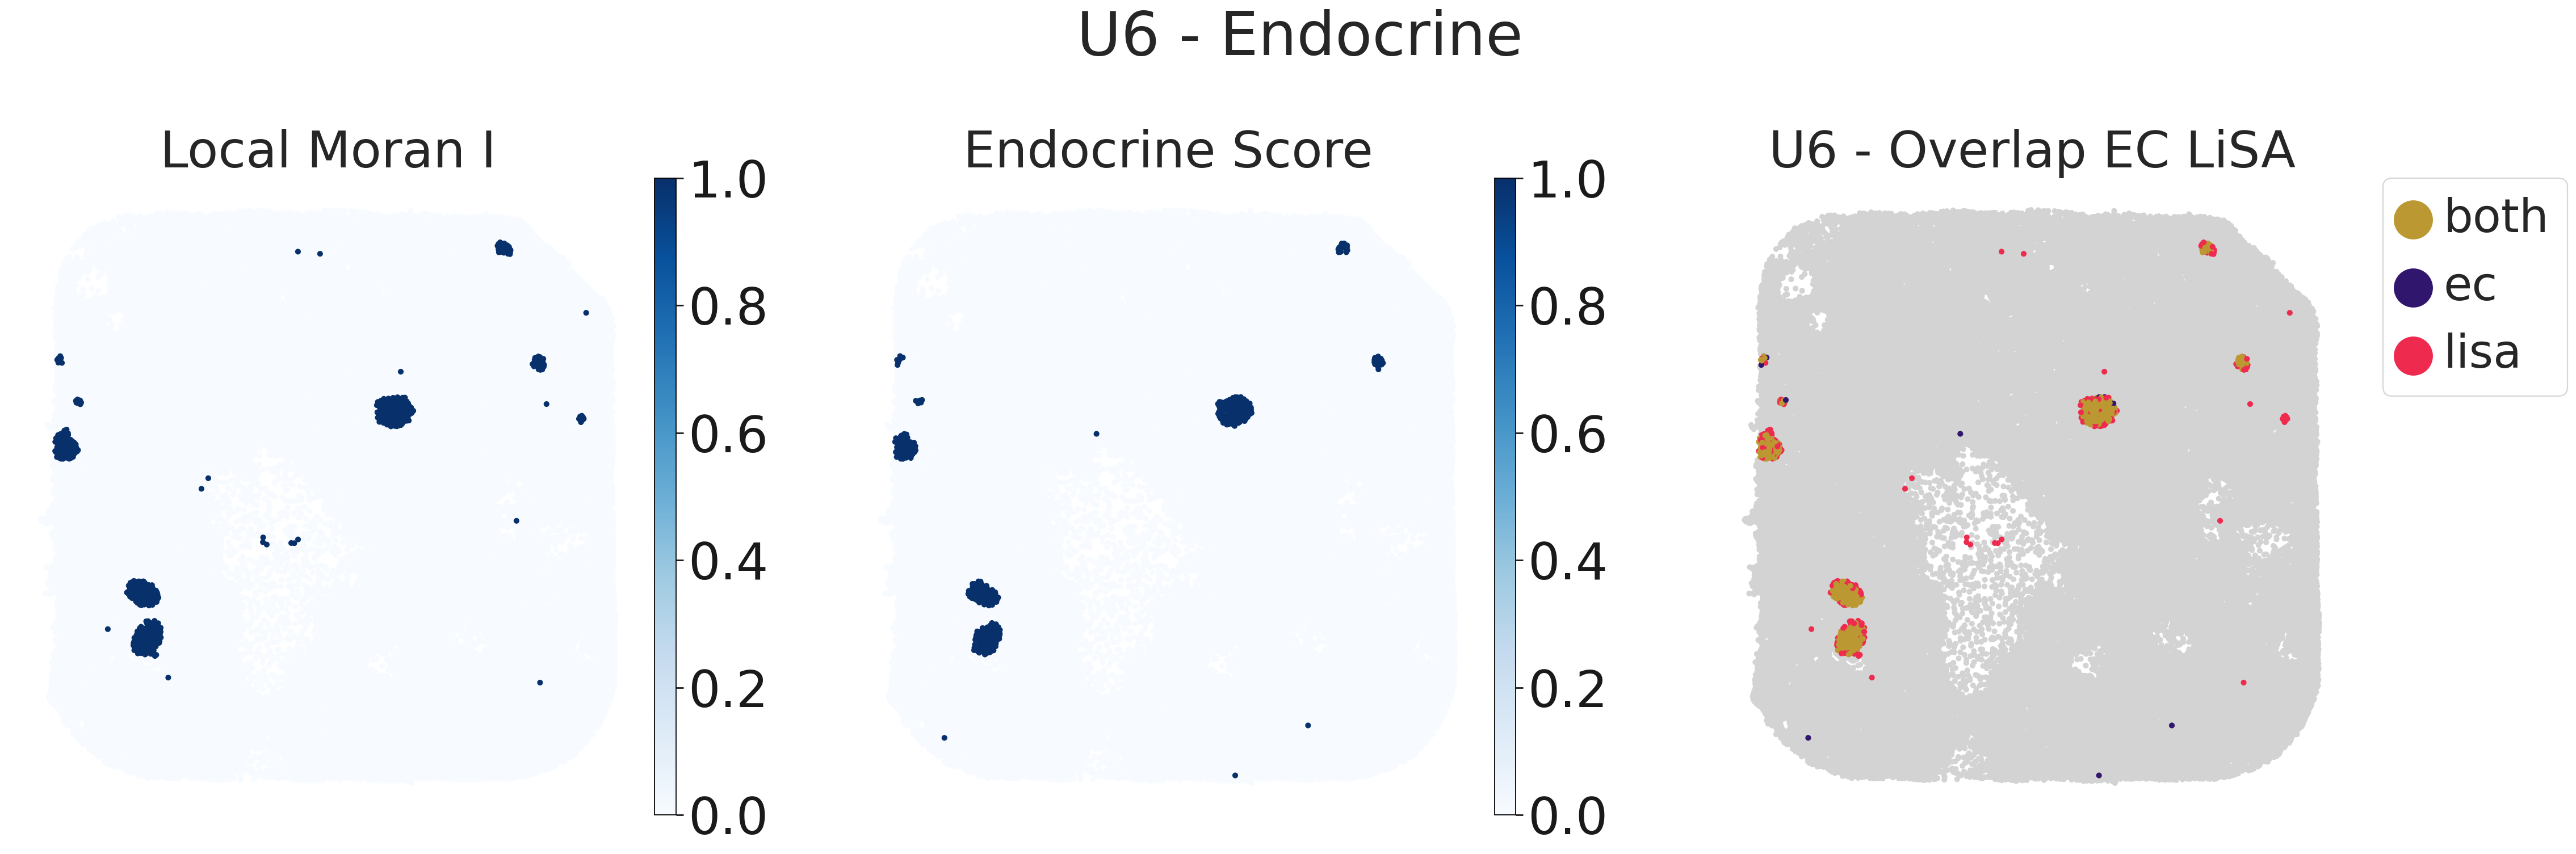

In [ ]:
sc.settings.set_figure_params(dpi=80, figsize = (10,10), fontsize=40)
cell_type = 'Endocrine'

for donor in ['U6']:#adata.obs.donor.unique():
    fig, axes = plt.subplots(1,3, figsize=(30, 10))
    ax = axes[2]


    sc.pl.spatial(
        adata[adata.obs.donor == donor],
        palette = palette_labels,
        color = ['labels'],
        spot_size=30,
        ax=ax,
        cmap = 'Blues',
        ncols=1,  # Only 1 plot per ax
        vmin=0,
        vmax=1,
        legend_fontsize=20,
        title=f'{donor} - Overlap EC LiSA',
        show=False
    )
    leg = ax.get_legend()
    if leg is not None:
        labels  = [t.get_text() for t in leg.get_texts()]
        handles = leg.legend_handles
        keep = [i for i, lab in enumerate(labels) if lab.upper() != "NA" and lab.lower() != "nan"]
        leg.remove()
        ax.legend([handles[i] for i in keep], [labels[i] for i in keep],
                bbox_to_anchor=(1.05, 1), loc='upper left',
                markerscale=5, borderaxespad=0.)

    ax.set_xlabel("")
    ax.set_ylabel("")
    for spine in ax.spines.values():
            spine.set_visible(False)

    ax = axes[0]

    sc.pl.spatial(
        adata[adata.obs.donor == donor],
        cmap="Blues",
        color=[f'lisa_selected'],
        spot_size=30,
        ax=ax,
        ncols=2,  # Only 1 plot per ax
        vmin=0,
        vmax='p99.2',
        legend_fontsize=20,
        title=f'Local Moran I',
        show=False
    )

    ax.set_xlabel("")
    ax.set_ylabel("")
    for spine in ax.spines.values():
            spine.set_visible(False)
    
    ax = axes[1]

    sc.pl.spatial(
        adata[adata.obs.donor == donor],
        cmap="Blues",
        color=[f'ec_selected'],
        spot_size=30,
        ax=ax,
        ncols=2,  # Only 1 plot per ax
        vmin=0,
        vmax='p99.2',
        legend_fontsize=20,
        title=f'Endocrine Score',
        show=False
    )

    ax.set_xlabel("")
    ax.set_ylabel("")
    for spine in ax.spines.values():
            spine.set_visible(False)
    plt.suptitle(f'{donor} - Endocrine')
    plt.tight_layout()
    #plt.savefig(save_figures + f'{donor}_{cell_type}_moran_I_raw_spatial.png')
    plt.show()

# Step 5: Clustered the Labels Using Hierarchical Clustering

In [ ]:
# Notably: Some barcodes overlap...
adata.obs_names_make_unique()

Created new column called 'islet' with unique islet id for each sample and islet. 
- min cell per cluster: 3 (nothing less will be an islet)
- distance thresh : 30 -> need at least 3 neighbours within 30 micron to be islet

In [ ]:
# Hierarchical Clustering

from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, fcluster


adata.obs['islet'] = np.nan

distance_threshold = 30  # microns
min_cells_per_cluster = 3


for donor in adata.obs['donor'].unique():
    donor_mask = adata.obs['donor'] == donor
    donor_data = adata[donor_mask].copy()

    endo_mask = donor_data.obs['labels'].notna()
    endo_data = donor_data[endo_mask]
    
    if endo_data.n_obs < min_cells_per_cluster:
        continue

    # Coordinates
    coords = endo_data.obsm['spatial']
    dists = pdist(coords)

    # Clustering
    Z = linkage(dists, method='single')
    cluster_labels = fcluster(Z, t=distance_threshold, criterion='distance')

    # Filter by size
    cluster_counts = pd.Series(cluster_labels).value_counts()
    valid_clusters = cluster_counts[cluster_counts >= min_cells_per_cluster].index

    # Map to IDs:
    cluster_id_map = {c: f"{donor}_{i}" for i, c in enumerate(valid_clusters)}
    islet_ids = [cluster_id_map[c] if c in cluster_id_map else np.nan for c in cluster_labels]

    adata.obs.loc[endo_data.obs_names, 'islet'] = pd.Series(islet_ids, index=endo_data.obs_names)

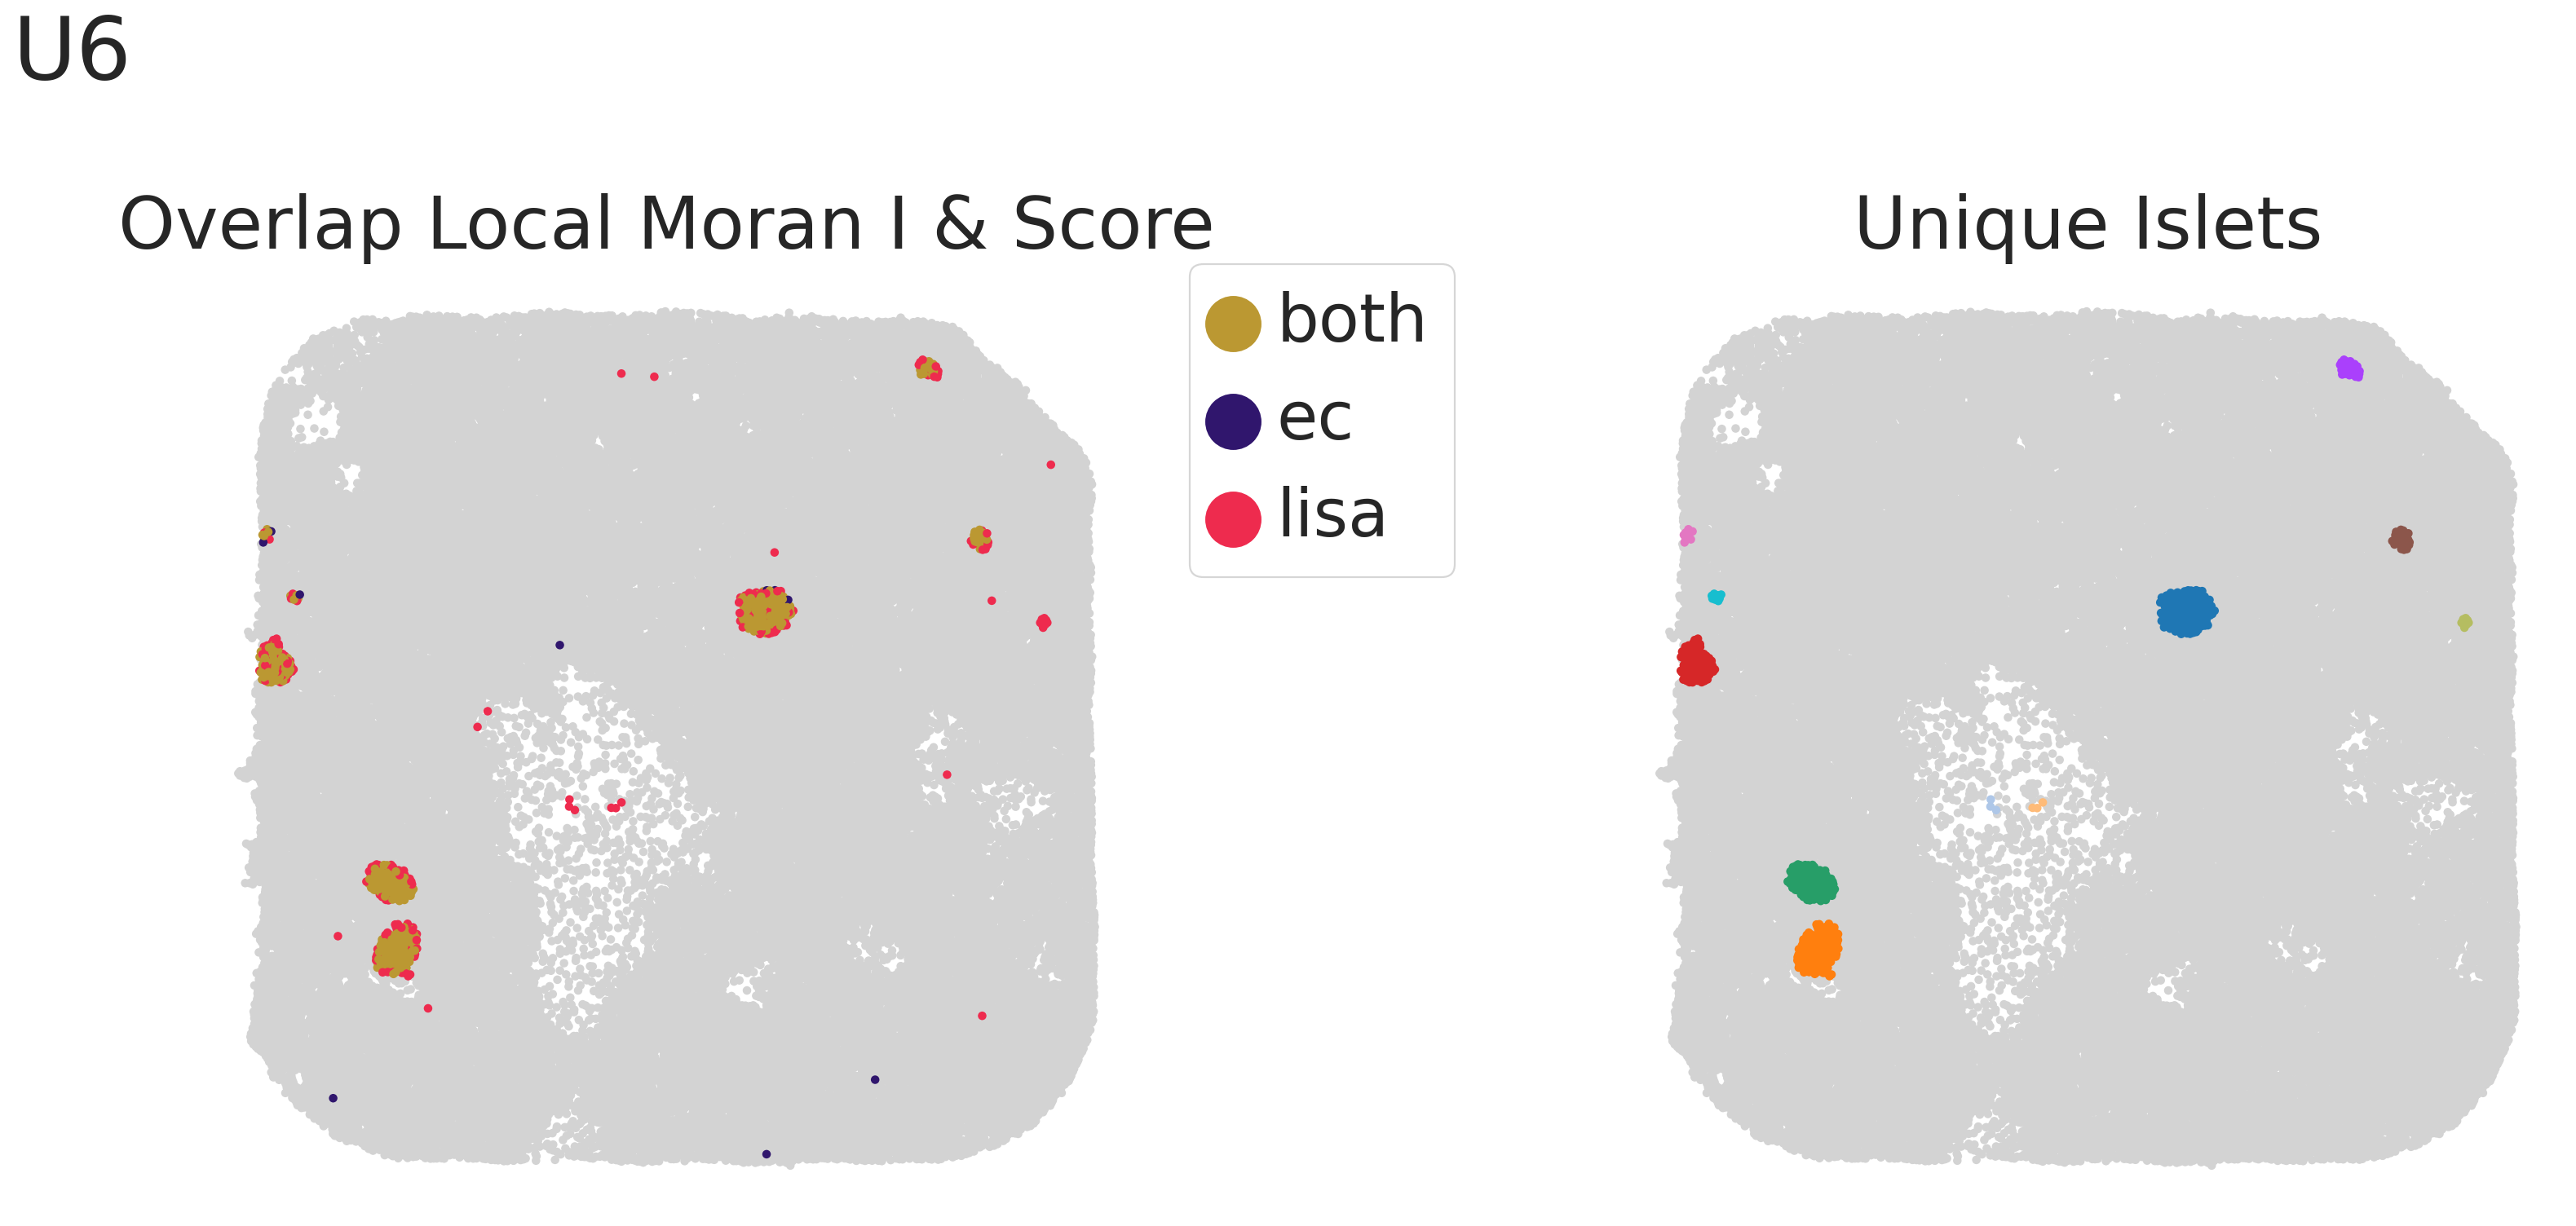

In [ ]:
sc.settings.set_figure_params(dpi=80, figsize = (10,10), fontsize=40)

for donor in ['U6']:
    fig, axes = plt.subplots(1,2,figsize=(20, 10))
    ax = axes[0]


    sc.pl.spatial(
        adata[adata.obs.donor == donor],
        palette = palette,
        color = ['labels'],
        spot_size=30,
        ax=ax,
        cmap = 'magma',
        ncols=1,  # Only 1 plot per ax
        vmin=0,
        vmax=1,
        legend_fontsize=15,
        title=f'Overlap Local Moran I & Score',
        show=False
    )
    leg = ax.get_legend()
    if leg is not None:
        labels  = [t.get_text() for t in leg.get_texts()]
        handles = leg.legend_handles
        keep = [i for i, lab in enumerate(labels) if lab.upper() != "NA" and lab.lower() != "nan"]
        leg.remove()
        ax.legend([handles[i] for i in keep], [labels[i] for i in keep],
                bbox_to_anchor=(1.05, 1), loc='upper left',
                markerscale=5, borderaxespad=0.)

    ax.set_xlabel("")
    ax.set_ylabel("")
    for spine in ax.spines.values():
            spine.set_visible(False)


    ax = axes[1]
    sc.pl.spatial(
        adata[adata.obs.donor == donor],
        #palette = palette(),
        color = ['islet'],
        spot_size=30,
        ax=ax,
        cmap = 'magma',
        ncols=1,  # Only 1 plot per ax
        vmin=0,
        vmax=1,
        #legend_fontsize=20,

        title=f'Unique Islets',
        
        show=False
    )
    leg = ax.get_legend()
    leg.remove()
    # if leg is not None:
    #     labels  = [t.get_text() for t in leg.get_texts()]
    #     handles = leg.legend_handles
    #     keep = [i for i, lab in enumerate(labels) if lab.upper() != "NA" and lab.lower() != "nan"]
    #     leg.remove()
    #     ax.legend([handles[i] for i in keep], [labels[i] for i in keep],
    #             bbox_to_anchor=(1.05, 1), loc='upper left',
    #             markerscale=5, borderaxespad=0.)

    ax.set_xlabel("")
    ax.set_ylabel("")
    for spine in ax.spines.values():
            spine.set_visible(False)
   
    plt.suptitle(f'{donor}', x = 0)
    plt.tight_layout()
    #plt.savefig(save_figures + f'{donor}_old_vs_new_spatial.png')
    plt.show()

# Step 6: Kept only islets with overlap for certainty

In [ ]:
# Select only data with labels == 'both'
df = adata.obs[adata.obs.labels == 'both'].copy()

In [ ]:
islets_to_keep = df.islet.unique()

adata.obs['islets_to_keep'] = np.nan

# Islets to keep are the ones with 'both' inside
for islet in islets_to_keep:
    adata.obs.loc[adata.obs.islet == islet, 'islets_to_keep'] = adata.obs[adata.obs.islet == islet].islet.values

In [ ]:
# Also annotate which islets are kept or not
keep_set = set(pd.Index(islets_to_keep).dropna())  # drop NaN if present

islets = adata.obs["islet"]
is_islet = islets.notna()
in_mask  = is_islet & islets.isin(keep_set)
out_mask = is_islet & ~islets.isin(keep_set)

adata.obs["islets_in_out"] = pd.Series(np.nan, index=adata.obs.index, dtype="object")
adata.obs.loc[in_mask,  "islets_in_out"] = "in"
adata.obs.loc[out_mask, "islets_in_out"] = "out"

In [63]:
print(sns.color_palette("rocket").as_hex())

['#35193e', '#701f57', '#ad1759', '#e13342', '#f37651', '#f6b48f']


In [71]:
palette_in_out = {'out':'#35193e', 'in': '#f6b48f'}

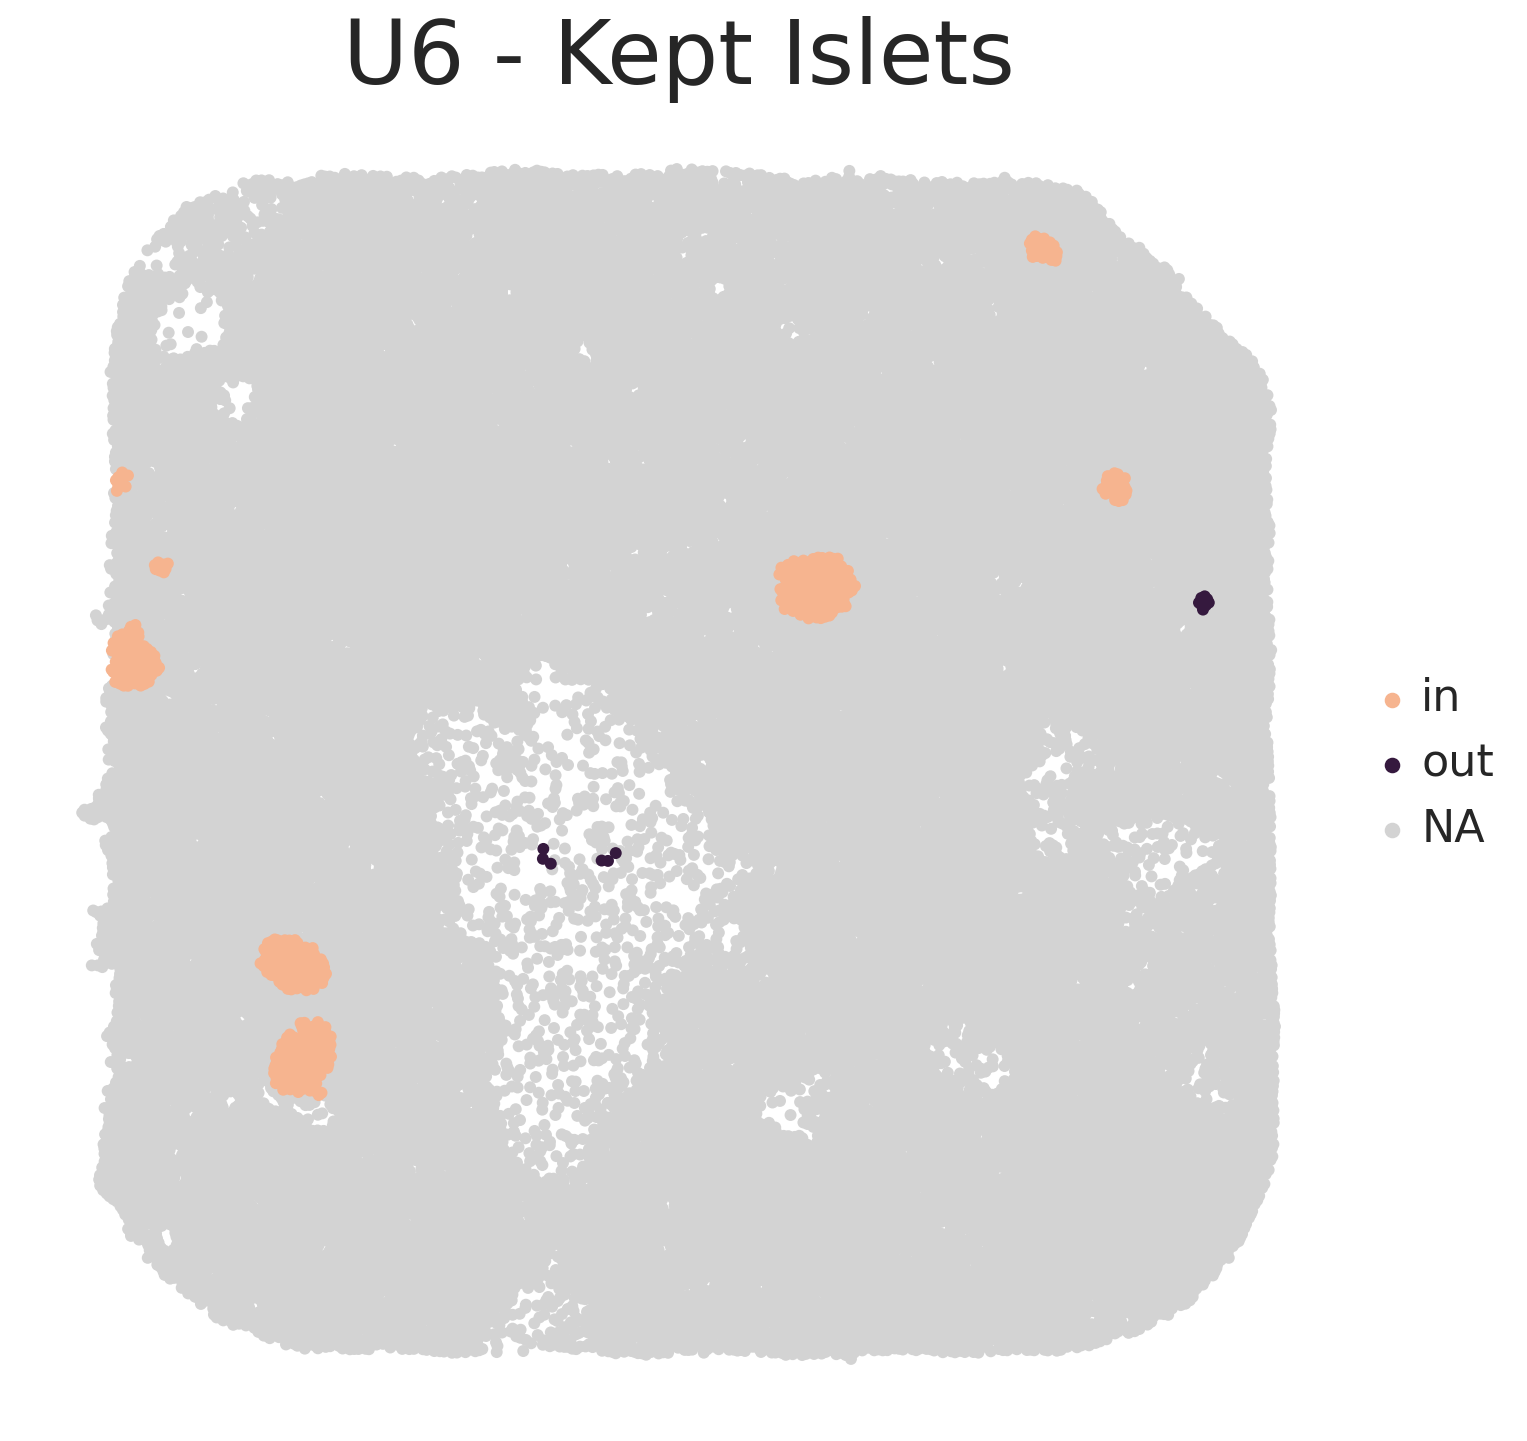

In [ ]:
sc.settings.set_figure_params(dpi=80, figsize = (10,10), fontsize=40)

for donor in ['U6']:#adata.obs.donor.unique():
    fig, axes = plt.subplots(1,1,figsize=(20, 10))
    ax = axes


    sc.pl.spatial(
        adata[adata.obs.donor == donor],
        palette = palette_in_out,
        color = ['islets_in_out'],
        spot_size=30,
        ax=ax,
        ncols=1,  # Only 1 plot per ax
        #vmin=0,
        #vmax='p99.2',
        legend_fontsize=20,
        title=f'{donor} - Kept Islets',
        show=False
    )
    # leg = ax.get_legend()
    # leg.remove()


    ax.set_xlabel("")
    ax.set_ylabel("")
    for spine in ax.spines.values():
            spine.set_visible(False)

    plt.tight_layout()
    #plt.savefig(save_figures + f'{donor}_old_vs_new_spatial.png')
    plt.show()



In [ ]:
sns.set_theme(font_scale=2)

def plot_islets_in_out_by_donor(adata, as_percent=True, save_path=None,
                                colors={"in":"#4CAF50", "out":"#E57373"}):
    cats = ["in", "out"]

    df = adata.obs.loc[:, ["donor", "islet", "islets_in_out"]].copy()

    # keep only rows that belong to an islet
    df = df.dropna(subset=["islet"])

    # one row per (donor, islet) with its in/out status
    # (robust even if a few spots were mislabeled inside the same islet)
    iso = (
        df.groupby(["donor", "islet"])["islets_in_out"]
          .apply(lambda s: "in" if (s == "in").any()
                           else ("out" if (s == "out").any() else np.nan))
          .reset_index(name="status")
          .dropna(subset=["status"])
    )

    # counts per donor
    counts = (
        iso.groupby(["donor", "status"]).size()
           .unstack(fill_value=0)
           .reindex(columns=cats, fill_value=0)
           .sort_index()
    )

    plot_data = (
        counts.div(counts.sum(axis=1), axis=0).mul(100)
        if as_percent else counts
    )

    fig, ax = plt.subplots(figsize=(30, 10))
    bottom = np.zeros(len(plot_data), dtype=float)

    for c in cats:
        ax.bar(
            plot_data.index, plot_data[c].values,
            bottom=bottom,
            label=c, color=colors.get(c, None),
            edgecolor="white", linewidth=0.5
        )
        bottom += plot_data[c].values.astype(float)

    ax.set_xlabel("")
    ax.set_ylabel("% of islets" if as_percent else "Number of islets")
    if as_percent:
        ax.set_ylim(0, 100)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title=None, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200)
    plt.show()



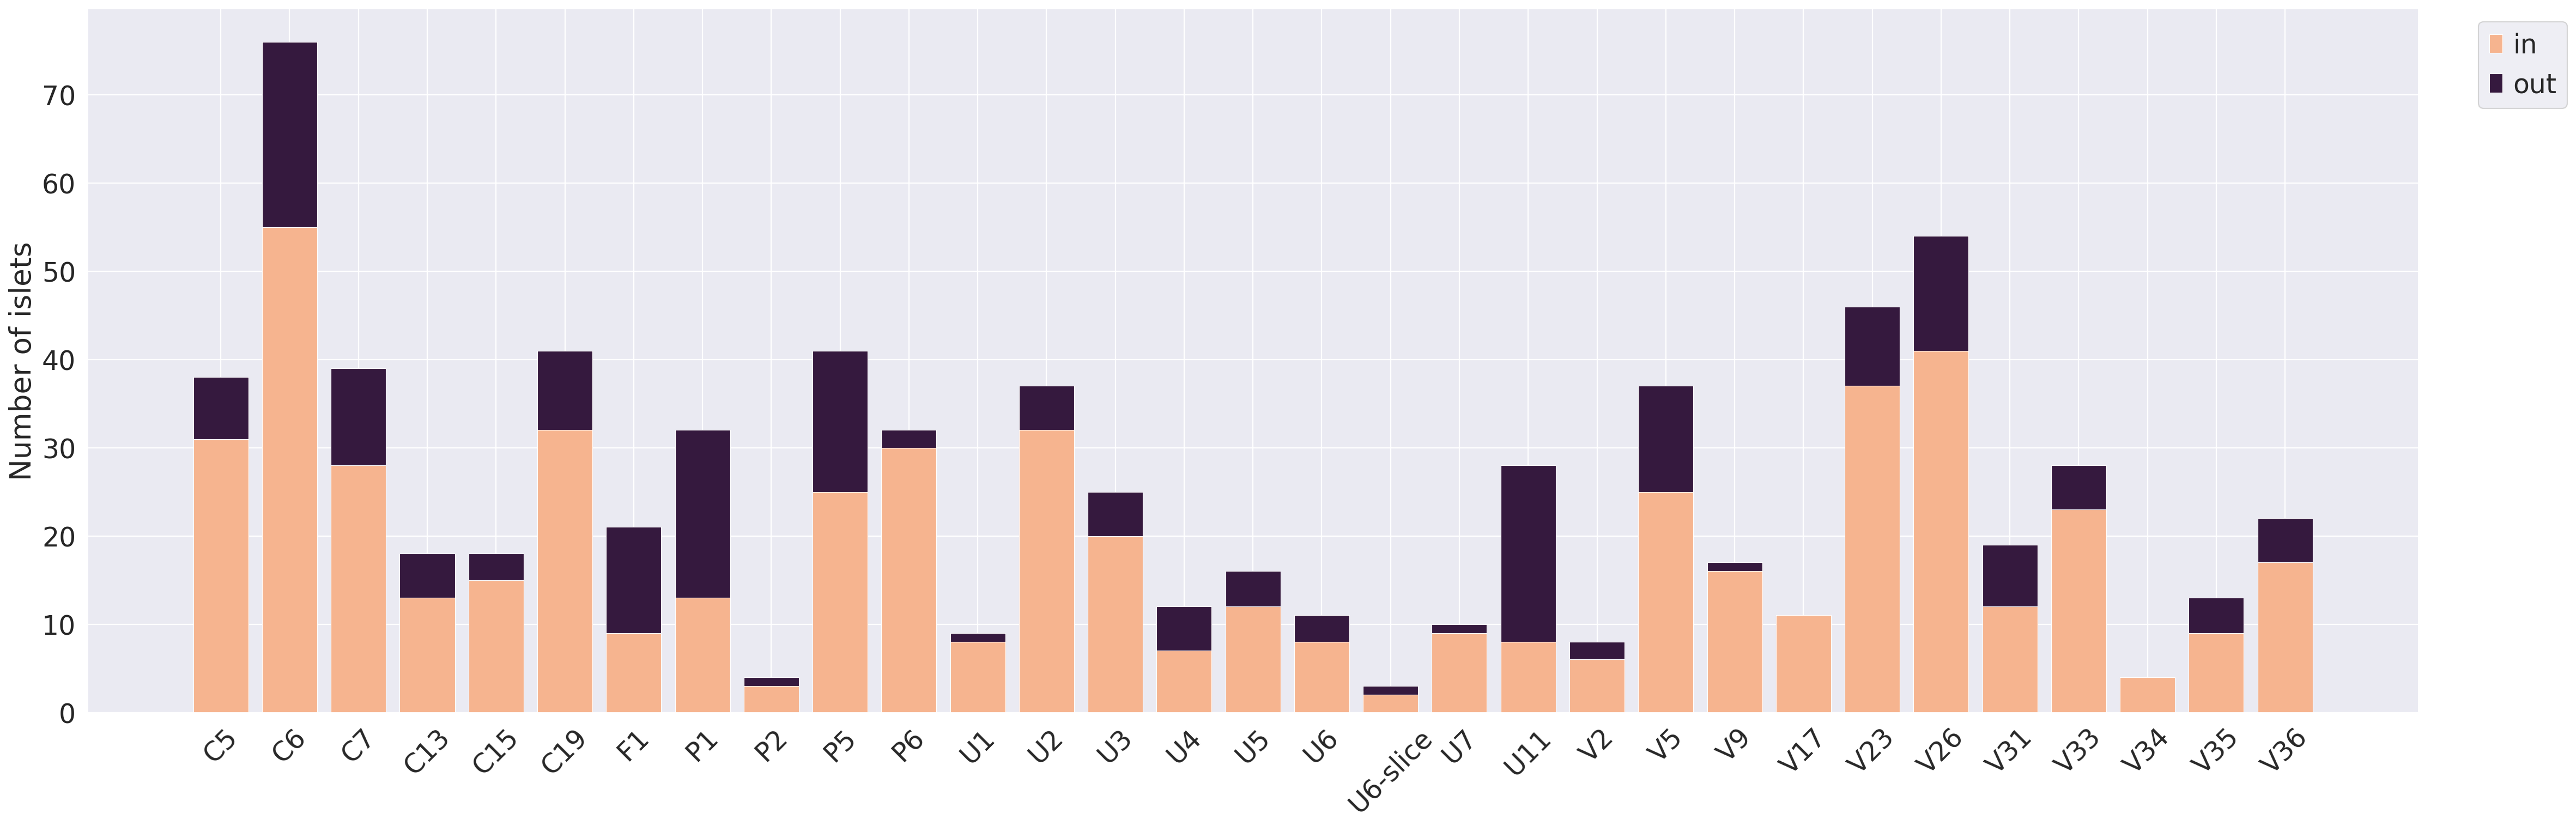

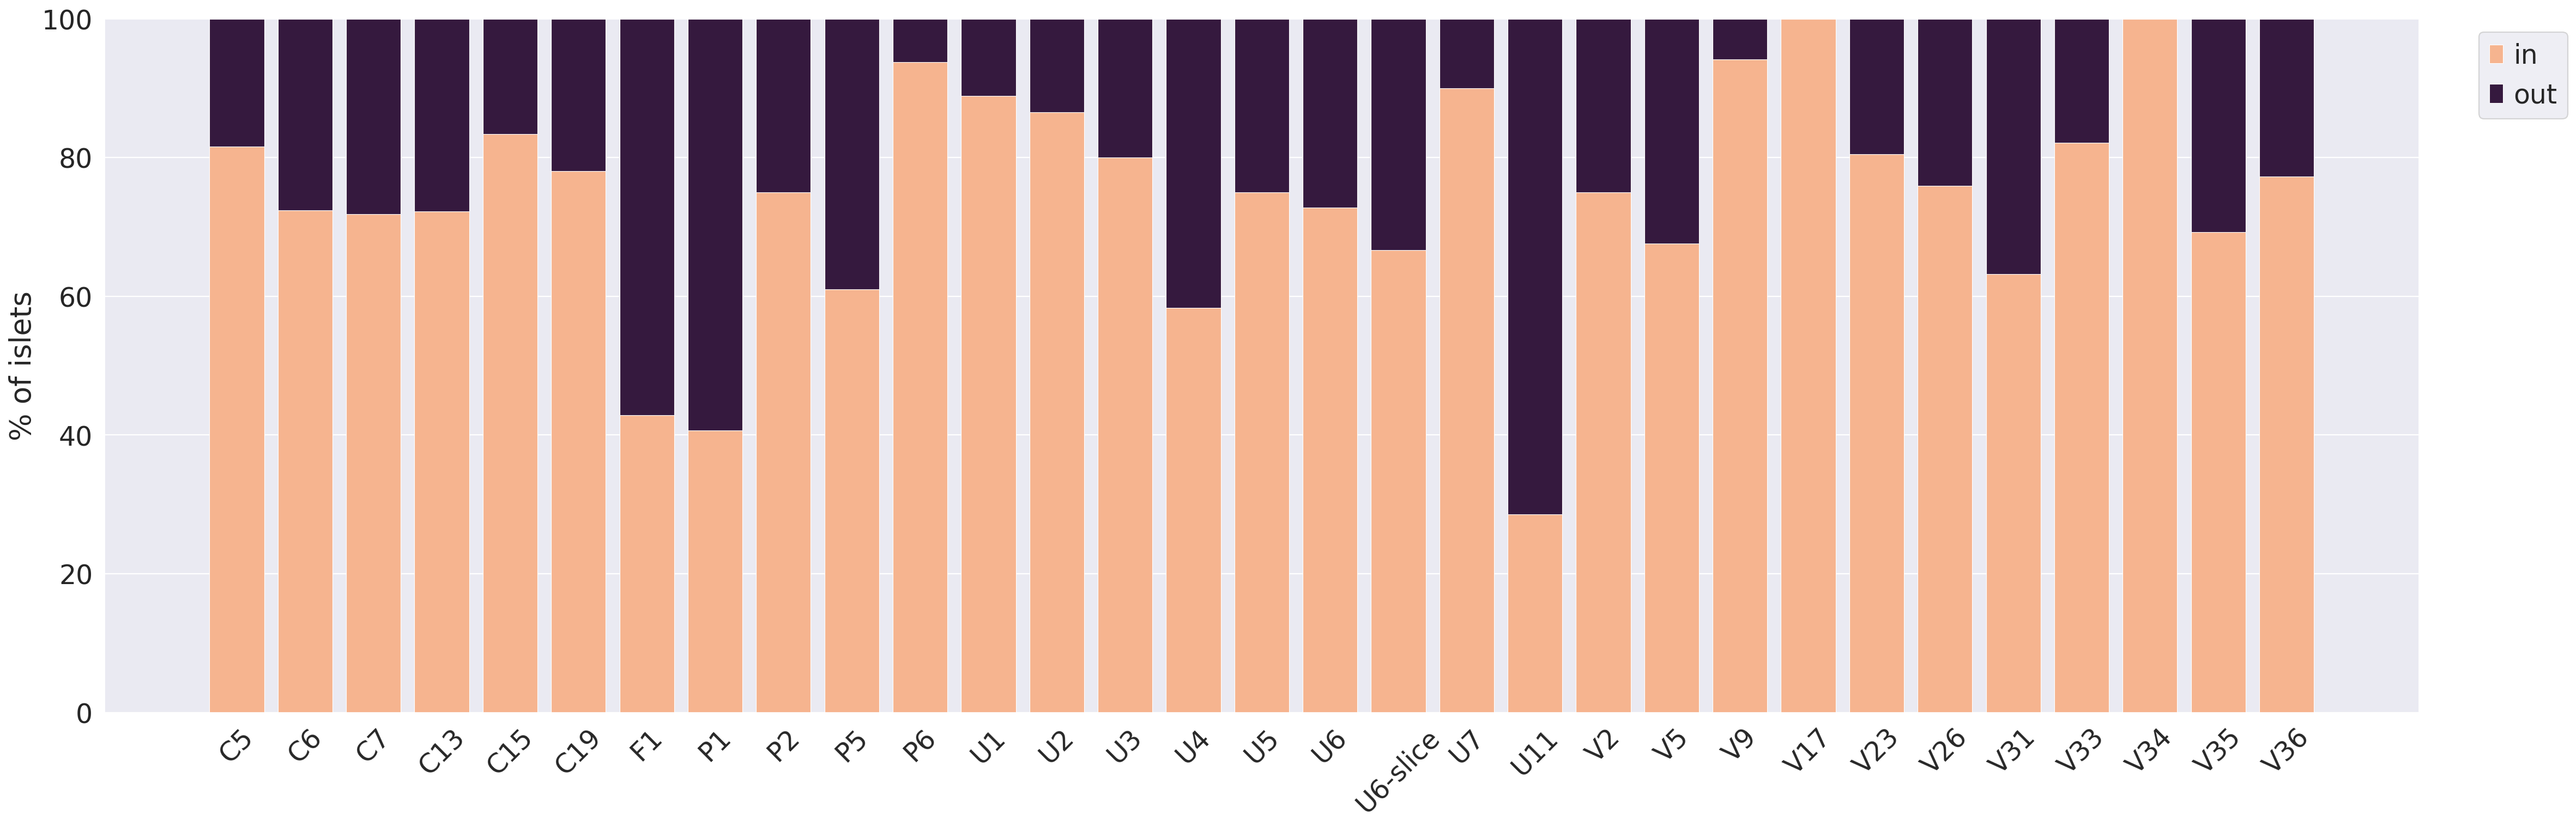

In [ ]:
plot_islets_in_out_by_donor(adata, as_percent=False, colors=palette_in_out)#, save_path=save_figures + "islets_in_out_by_donor.png")
plot_islets_in_out_by_donor(adata, as_percent=True,colors=palette_in_out)#, save_path=save_figures + "islets_in_out_by_donor_pct.png")

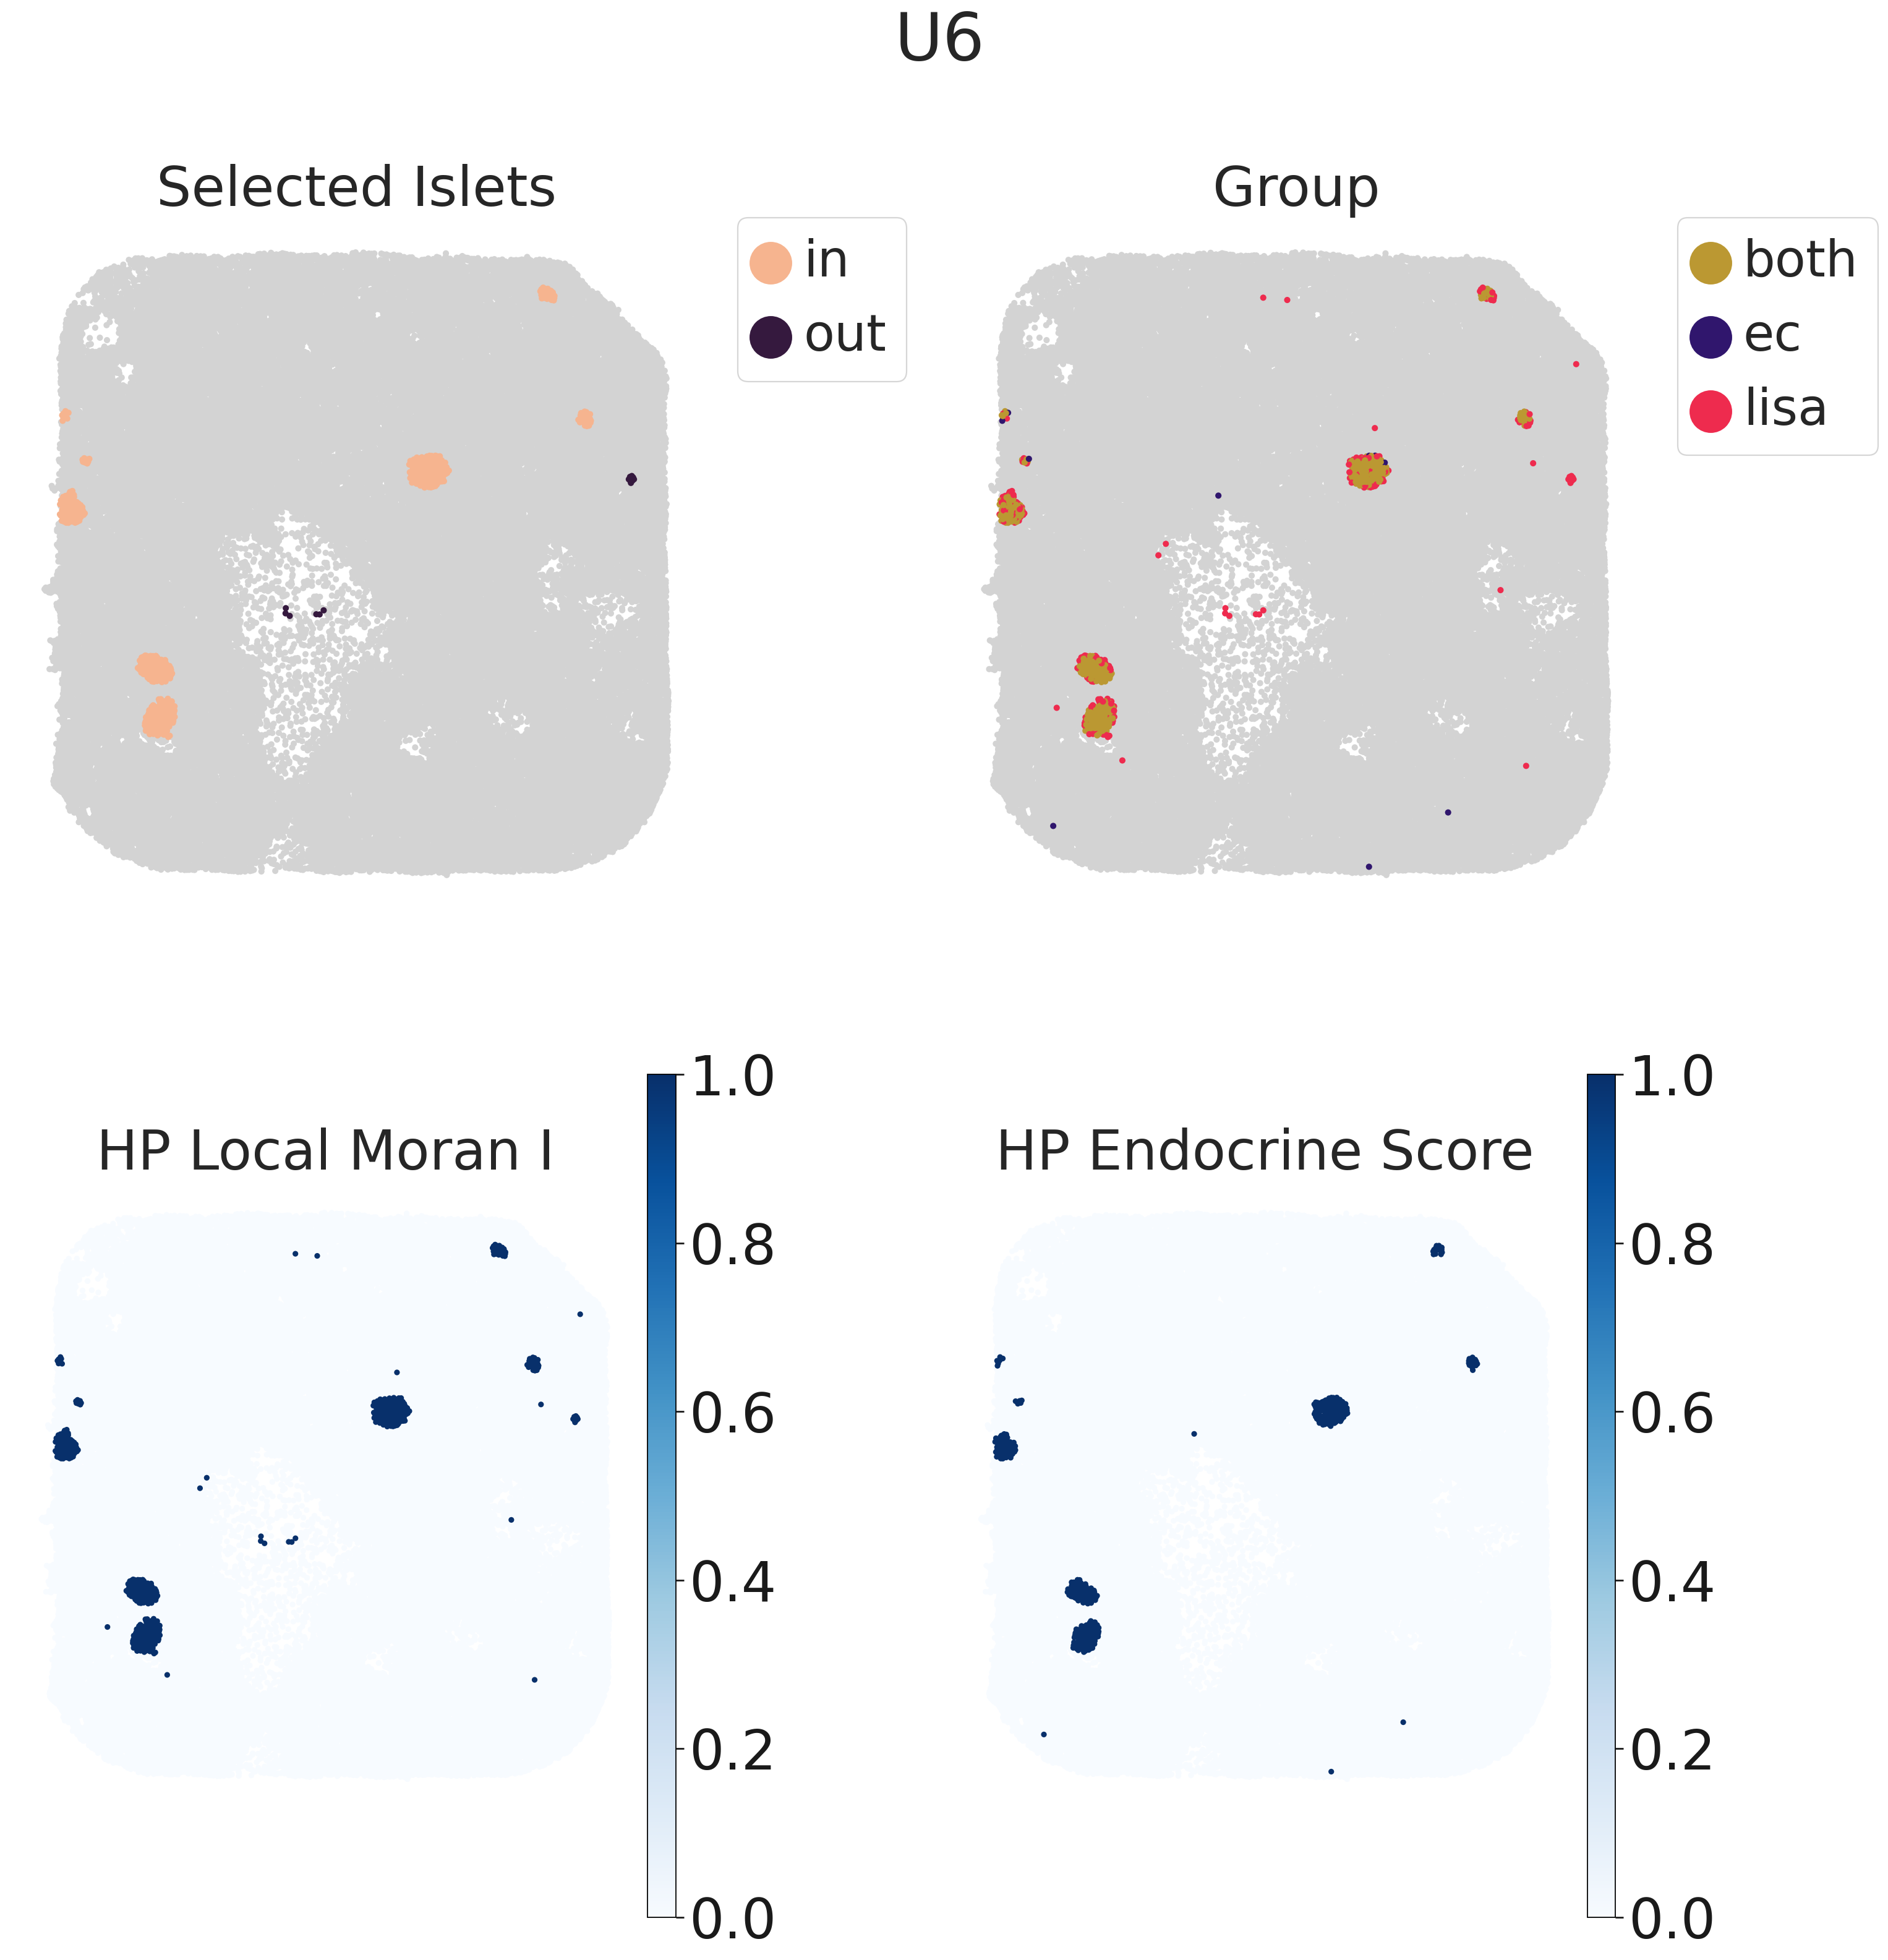

In [ ]:
sc.settings.set_figure_params(dpi=80, figsize = (10,10), fontsize=40)

for donor in ['U6']:#adata.obs.donor.unique():
    fig, axes = plt.subplots(2,2,figsize=(20, 20))
   
    ax = axes[1,1]


    sc.pl.spatial(
        adata[adata.obs.donor == donor],
        #palette = palette(),
        color = ['ec_selected'],
        spot_size=30,
        ax=ax,
        cmap = 'Blues',
        ncols=1,  # Only 1 plot per ax
        vmin=0,
        vmax="p99.5",
        legend_fontsize=20,
        title=f'HP Endocrine Score',
        show=False
    )
    leg = ax.get_legend()
    if leg is not None:
        labels  = [t.get_text() for t in leg.get_texts()]
        handles = leg.legend_handles
        keep = [i for i, lab in enumerate(labels) if lab.upper() != "NA" and lab.lower() != "nan"]
        leg.remove()
        ax.legend([handles[i] for i in keep], [labels[i] for i in keep],
                bbox_to_anchor=(1.05, 1), loc='upper left',
                markerscale=5, borderaxespad=0.)

    ax.set_xlabel("")
    ax.set_ylabel("")
    for spine in ax.spines.values():
            spine.set_visible(False)


    ax = axes[0,1]


    sc.pl.spatial(
        adata[adata.obs.donor == donor],
        palette = palette_labels,
        color = ['labels'],
        spot_size=30,
        ax=ax,
        cmap = 'magma',
        ncols=1,  # Only 1 plot per ax
        vmin=0,
        vmax=1,
        legend_fontsize=20,
        title=f'Group',
        show=False
    )
    leg = ax.get_legend()
    if leg is not None:
        labels  = [t.get_text() for t in leg.get_texts()]
        handles = leg.legend_handles
        keep = [i for i, lab in enumerate(labels) if lab.upper() != "NA" and lab.lower() != "nan"]
        leg.remove()
        ax.legend([handles[i] for i in keep], [labels[i] for i in keep],
                bbox_to_anchor=(1.05, 1), loc='upper left',
                markerscale=5, borderaxespad=0.)

    ax.set_xlabel("")
    ax.set_ylabel("")
    for spine in ax.spines.values():
            spine.set_visible(False)



    ax = axes[0,0]
    sc.pl.spatial(
        adata[adata.obs.donor == donor],
        palette = palette_in_out,
        color = ['islets_in_out'],
        spot_size=30,
        ax=ax,
        cmap = 'magma',
        ncols=1,  # Only 1 plot per ax
        vmin=0,
        vmax=1,
        legend_fontsize=20,
        title=f'Selected Islets',
        show=False
    )
    leg = ax.get_legend()
    if leg is not None:
        labels  = [t.get_text() for t in leg.get_texts()]
        handles = leg.legend_handles
        keep = [i for i, lab in enumerate(labels) if lab.upper() != "NA" and lab.lower() != "nan"]
        leg.remove()
        ax.legend([handles[i] for i in keep], [labels[i] for i in keep],
                bbox_to_anchor=(1.05, 1), loc='upper left',
                markerscale=5, borderaxespad=0.)

    ax.set_xlabel("")
    ax.set_ylabel("")

    for spine in ax.spines.values():
            spine.set_visible(False)

    ax = axes[1,0]
    sc.pl.spatial(
        adata[adata.obs.donor == donor],
        #palette = palette(),
        color = ['lisa_selected'],
        spot_size=30,
        ax=ax,
        cmap = 'Blues',
        ncols=1,  # Only 1 plot per ax
        vmin=0,
        vmax="p99.5",
        legend_fontsize=20,
        title=f'HP Local Moran I',
        show=False
    )
    leg = ax.get_legend()
    if leg is not None:
        labels  = [t.get_text() for t in leg.get_texts()]
        handles = leg.legend_handles
        keep = [i for i, lab in enumerate(labels) if lab.upper() != "NA" and lab.lower() != "nan"]
        leg.remove()
        ax.legend([handles[i] for i in keep], [labels[i] for i in keep],
                bbox_to_anchor=(1.05, 1), loc='upper left',
                markerscale=5, borderaxespad=0.)

    ax.set_xlabel("")
    ax.set_ylabel("")
    for spine in ax.spines.values():
            spine.set_visible(False)

    plt.tight_layout()
    plt.suptitle(f'{donor}', x = 0.5,y=1.01)
    #plt.savefig(save_figures + f'{donor}_old_vs_new_spatial.png')
    plt.show()